# 1. DESCARGA DEL DATASET DESDE LA URL OFICIAL

El artículo usa 2014 para clustering y entrenamiento (enero-noviembre) y evaluación (diciembre). Se reproduce lo indicado


In [2]:
# 1.1 Descargar datos
import urllib.request
import zipfile
import io
import pandas as pd

print("DESCARGA DEL DATASET")
url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
with urllib.request.urlopen(url) as response:
    zip_data = io.BytesIO(response.read())
with zipfile.ZipFile(zip_data) as zip_file:
    with zip_file.open('LD2011_2014.txt') as file:
        df_raw = pd.read_csv(file, sep=';', decimal=',', low_memory=False)

# 1.2 Procesamiento básico
df_raw.rename(columns={df_raw.columns[0]: 'datetime'}, inplace=True)
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], dayfirst=False)
df_raw.set_index('datetime', inplace=True)
df_raw = df_raw.dropna()

# 1.3 Filtrar por año 2014
df_2014 = df_raw[df_raw.index.year == 2014]

# 1.4 Dividir en entrenamiento (enero-noviembre) y test (diciembre)
train_start = '2014-01-01'
train_end = '2014-11-30 23:45:00'
test_start = '2014-12-01'
test_end = '2014-12-31 23:45:00'

df_train = df_2014[(df_2014.index >= train_start) & (df_2014.index <= train_end)]
df_test  = df_2014[(df_2014.index >= test_start) & (df_2014.index <= test_end)]

print(f"Entrenamiento: {len(df_train)} filas, desde {df_train.index.min()} hasta {df_train.index.max()}")
print(f"Test: {len(df_test)} filas, desde {df_test.index.min()} hasta {df_test.index.max()}")

DESCARGA DEL DATASET
Entrenamiento: 32064 filas, desde 2014-01-01 00:00:00 hasta 2014-11-30 23:45:00
Test: 2976 filas, desde 2014-12-01 00:00:00 hasta 2014-12-31 23:45:00


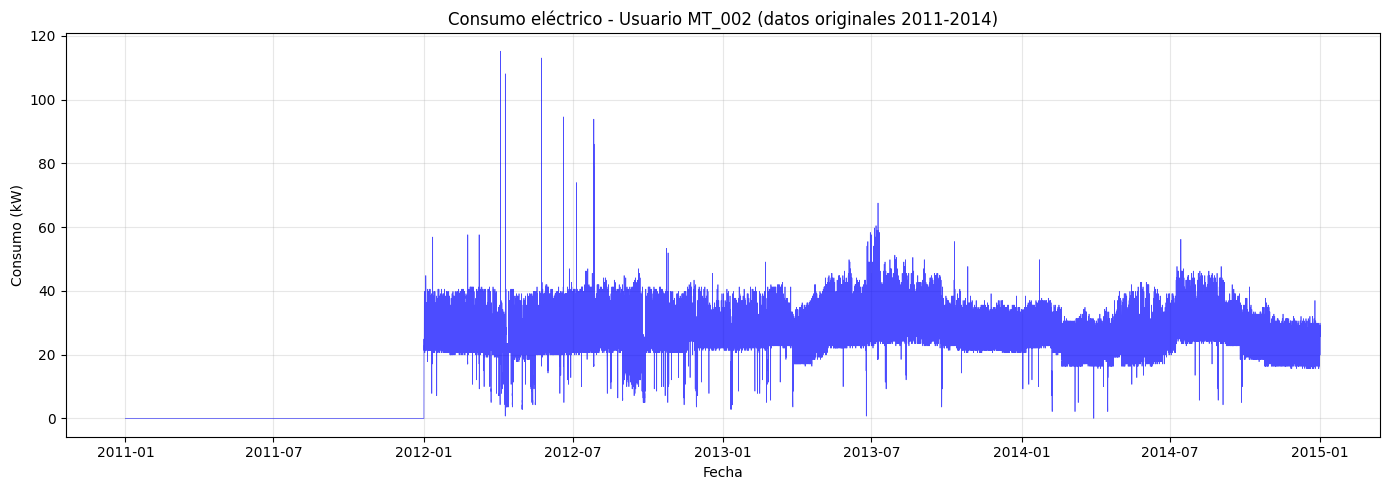

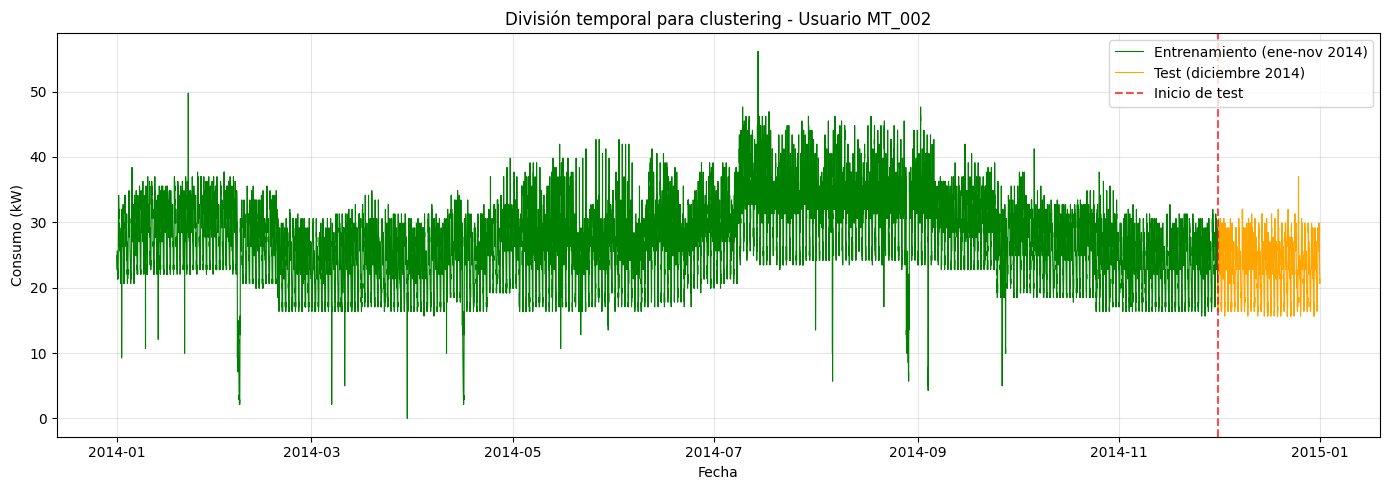

In [3]:
# Gráfico 1: Consumo de un usuario en todo el período original
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Tomamos un consumidor de ejemplo (el primero)
user_example = df_raw.columns[1]  # o df_processed.columns[0]
data_user = df_raw[user_example].dropna()  # datos crudos

plt.figure(figsize=(14, 5))
plt.plot(data_user.index, data_user.values, linewidth=0.5, color='blue', alpha=0.7)
plt.title(f'Consumo eléctrico - Usuario {user_example} (datos originales 2011-2014)', fontsize=12)
plt.xlabel('Fecha')
plt.ylabel('Consumo (kW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Entrenamiento (enero-nov 2014) vs test (diciembre 2014) para clustering
# Usamos el mismo usuario para ilustrar la partición temporal
train_dates = (df_2014.index.year == 2014) & (df_2014.index.month <= 11)
test_dates = (df_2014.index.year == 2014) & (df_2014.index.month == 12)

data_train = df_2014.loc[train_dates, user_example]
data_test = df_2014.loc[test_dates, user_example]

plt.figure(figsize=(14, 5))
plt.plot(data_train.index, data_train.values, linewidth=0.8, color='green', label='Entrenamiento (ene-nov 2014)')
plt.plot(data_test.index, data_test.values, linewidth=0.8, color='orange', label='Test (diciembre 2014)')
plt.axvline(pd.Timestamp('2014-12-01'), color='red', linestyle='--', alpha=0.7, label='Inicio de test')
plt.title(f'División temporal para clustering - Usuario {user_example}', fontsize=12)
plt.xlabel('Fecha')
plt.ylabel('Consumo (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Opcional: superponer centroides (si ya los tenemos)
# Los centroides están en escala original y tienen la misma longitud que el período de entrenamiento (ene-nov)
# Para visualizar, podemos graficar los centroides ajustados a la misma escala temporal
if 'centroids_original' in locals():
    import numpy as np
    # Crear un rango de tiempo para los centroides (enero-nov 2014)
    train_time = pd.date_range(start='2014-01-01', periods=len(centroids_original[0]), freq='15T')
    plt.figure(figsize=(14, 5))
    for i, centroid in enumerate(centroids_original):
        plt.plot(train_time, centroid, linewidth=1.5, label=f'Centroide cluster {i}')
    plt.title('Centroides de clusters obtenidos (entrenamiento ene-nov 2014)', fontsize=12)
    plt.xlabel('Fecha')
    plt.ylabel('Consumo (kW)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Etapa 2: Preprocesamiento, características temporales y medias móviles
Siguiendo el artículo (sección III-C):
El artículo establece que el vector de entrada para la LSTM debe contener:

Día de la semana (day_of_week)

Día del mes (day_of_month)

Mes del año (month)

Franja horaria (timeslice, 6 intervalos de 4 horas)

Consumo medio de la hora anterior (avg_previous_hour)

Consumo medio de la hora antepenúltima (avg_previous_2hour)

Además, el valor real de consumo se usa como etiqueta.



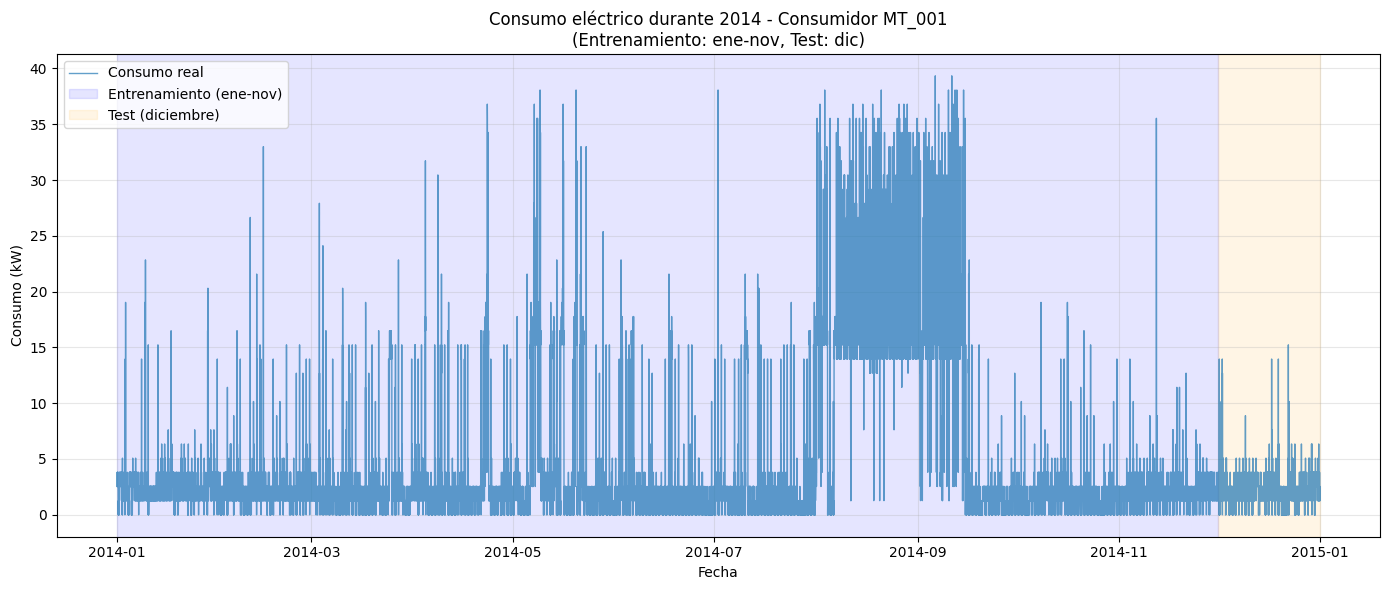

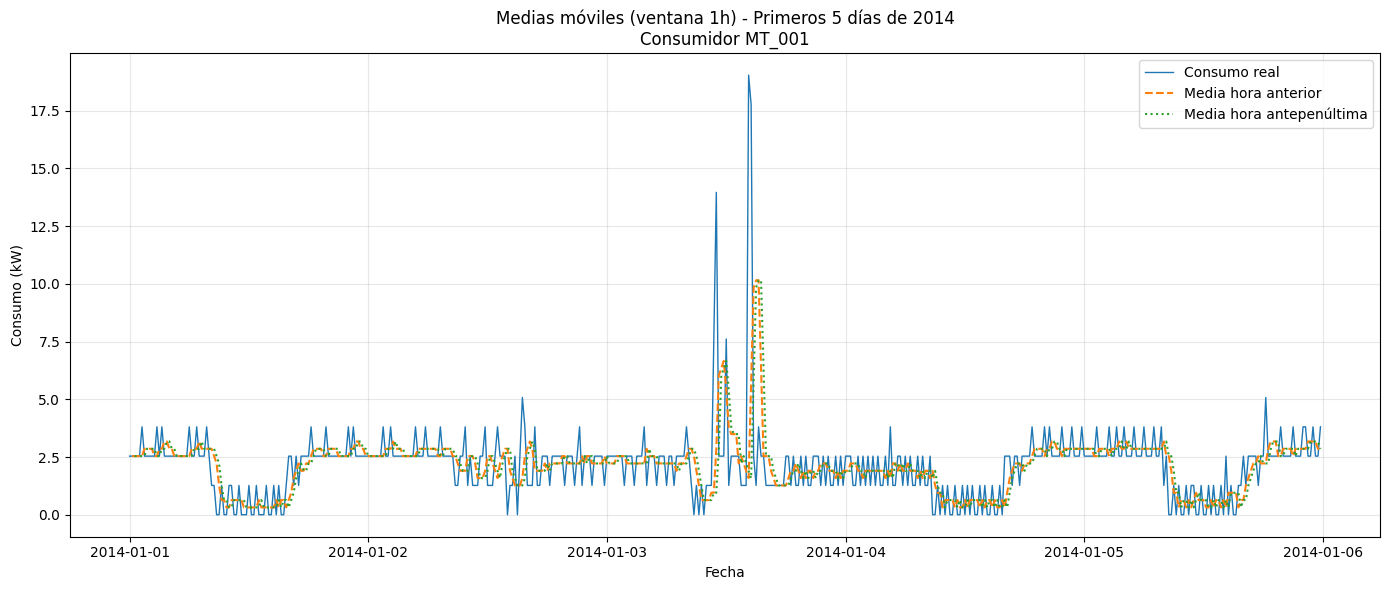

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Suponemos que ya tenemos df_2014 (todo el año 2014)
# Definimos las fechas de corte
train_end = '2014-11-30 23:45:00'   # último instante de noviembre
test_start = '2014-12-01 00:00:00'  # primer instante de diciembre

# 2.1 Calcular características temporales para todo 2014
df = df_2014.copy()
df['day_of_week'] = df.index.dayofweek
df['day_of_month'] = df.index.day
df['month'] = df.index.month
df['hour'] = df.index.hour
df['minute'] = df.index.minute
df['timeslice'] = df.index.hour // 4   # 0-5

# 2.2 Calcular medias móviles (ventana de 4 observaciones = 1 hora)
# Tomamos un consumidor de ejemplo (el primero, que suele ser MT_001)
consumidor_ejemplo = df.columns[0]
serie = df[consumidor_ejemplo]

# Media de la hora anterior (desplazada 1 paso)
avg_prev_hour = serie.rolling(4, min_periods=1).mean().shift(1)
# Media de la hora antepenúltima (desplazada 2 pasos)
avg_prev_2hour = serie.rolling(4, min_periods=1).mean().shift(2)

# Añadimos al DataFrame (opcional, útil luego para crear secuencias)
df[f'{consumidor_ejemplo}_avg_prev_hour'] = avg_prev_hour
df[f'{consumidor_ejemplo}_avg_prev_2hour'] = avg_prev_2hour

# 2.3 Visualización: serie temporal completa 2014 con partición train/test
plt.figure(figsize=(14, 6))
plt.plot(df.index, serie, label='Consumo real', linewidth=1, alpha=0.7)
plt.axvspan(df.index[0], pd.Timestamp(train_end), color='blue', alpha=0.1, label='Entrenamiento (ene-nov)')
plt.axvspan(pd.Timestamp(test_start), df.index[-1], color='orange', alpha=0.1, label='Test (diciembre)')
plt.title(f'Consumo eléctrico durante 2014 - Consumidor {consumidor_ejemplo}\n(Entrenamiento: ene-nov, Test: dic)')
plt.xlabel('Fecha')
plt.ylabel('Consumo (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2.4 Visualización de las medias móviles (primeros 5 días de enero)
plt.figure(figsize=(14, 6))
primeros_5dias = df[df.index < '2014-01-06']
plt.plot(primeros_5dias.index, primeros_5dias[consumidor_ejemplo], label='Consumo real', linewidth=1)
plt.plot(primeros_5dias.index, primeros_5dias[f'{consumidor_ejemplo}_avg_prev_hour'],
         label='Media hora anterior', linestyle='--', linewidth=1.5)
plt.plot(primeros_5dias.index, primeros_5dias[f'{consumidor_ejemplo}_avg_prev_2hour'],
         label='Media hora antepenúltima', linestyle=':', linewidth=1.5)
plt.title(f'Medias móviles (ventana 1h) - Primeros 5 días de 2014\nConsumidor {consumidor_ejemplo}')
plt.xlabel('Fecha')
plt.ylabel('Consumo (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Interpretación de las gráficas:

Primer gráfico: Muestra todo el año 2014, indicando en azul el período de entrenamiento (enero‑noviembre) y en naranja el período de prueba (diciembre). Esto refleja fielmente la partición temporal que usan los autores.

Segundo gráfico: Presenta un zoom de los primeros 5 días de enero, comparando el consumo real con las dos medias móviles calculadas (hora anterior y hora antepenúltima). Este tipo de características se introducirán en la LSTM para mejorar la predicción.

# Etapa 3: Clustering K‑Means sobre los datos de entrenamiento (enero‑noviembre 2014)
Siguiendo el artículo (sección III‑A y III‑C):
Los autores aplican un clustering K‑Means sobre los perfiles de consumo de los usuarios para extraer los centroides más representativos. Estos centroides se utilizarán posteriormente para entrenar la LSTM.
El artículo señala que probaron con K=2,3,4,5 y finalmente eligieron K=4 basándose en el rendimiento de la detección de anomalías (Precision=78%, Recall=88%).

Nosotros realizaremos el clustering únicamente sobre el período de entrenamiento (enero‑noviembre 2014). Luego visualizaremos los centroides resultantes.

CLUSTERING K-MEANS SOBRE DATOS DE ENTRENAMIENTO (ENERO-NOV 2014)
Entrenamiento: desde 2014-01-01 00:00:00 hasta 2014-11-30 23:45:00
Perfiles de usuario: 370 usuarios x 32064 observaciones
Valores ajustados por outliers: 163049
Datos normalizados: media=0.0000, std=1.0000
Probando K=2...
Probando K=3...
Probando K=4...
Probando K=5...
Probando K=6...
Probando K=7...
Probando K=8...
Probando K=9...
Probando K=10...

Resultados de la evaluación de K:
 K      Inercia  Silhouette
 2 3.515469e+06    0.968343
 3 1.160009e+06    0.963163
 4 6.406613e+05    0.849375
 5 4.275885e+05    0.846973
 6 2.966670e+05    0.846199
 7 1.815321e+05    0.818802
 8 1.094868e+05    0.700964
 9 8.320273e+04    0.656224
10 6.858975e+04    0.657309

Distribución de usuarios por cluster (K=4):
  Cluster 0: 346 usuarios (93.5%)
  Cluster 1: 1 usuarios (0.3%)
  Cluster 2: 3 usuarios (0.8%)
  Cluster 3: 20 usuarios (5.4%)


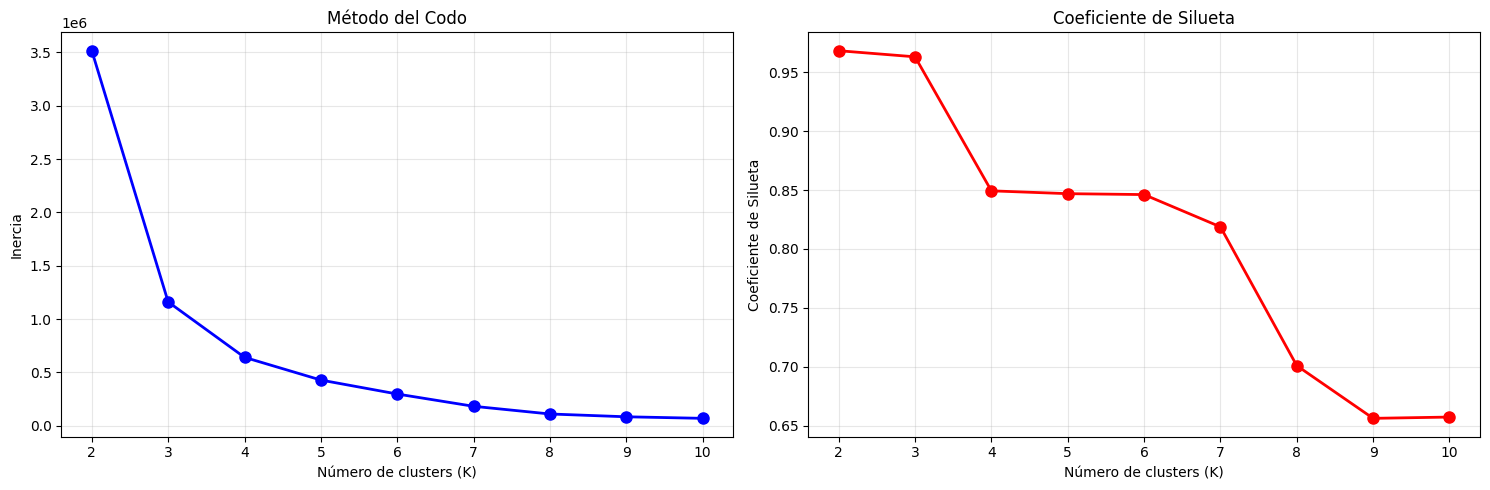

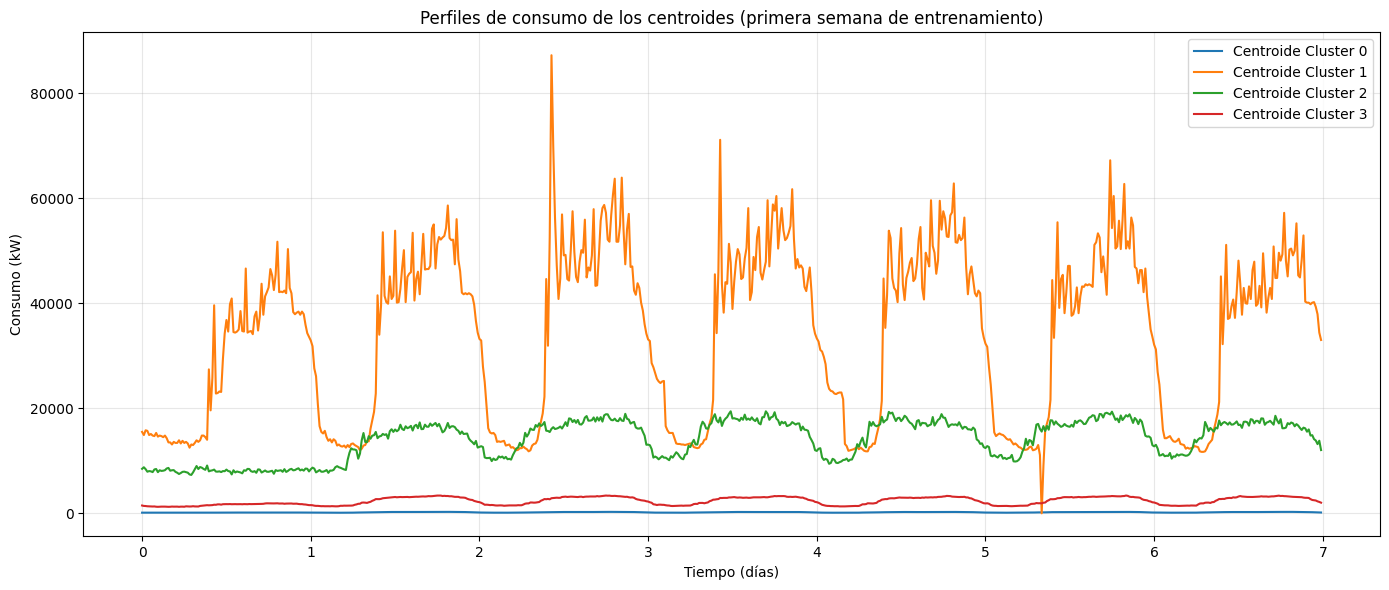


Centroides guardados. Listo para la fase de entrenamiento LSTM.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("CLUSTERING K-MEANS SOBRE DATOS DE ENTRENAMIENTO (ENERO-NOV 2014)")
print("=" * 60)

# 3.1 Filtrar datos de entrenamiento (enero a noviembre 2014)
train_mask = (df_2014.index.year == 2014) & (df_2014.index.month <= 11)
df_train = df_2014[train_mask].copy()
print(f"Entrenamiento: desde {df_train.index.min()} hasta {df_train.index.max()}")

# 3.2 Preparar perfiles de usuario: transponer (usuarios como filas, tiempo como columnas)
user_profiles = df_train.T
print(f"Perfiles de usuario: {user_profiles.shape[0]} usuarios x {user_profiles.shape[1]} observaciones")

# 3.3 Eliminación de outliers por IQR (por usuario)
Q1 = user_profiles.quantile(0.25, axis=1)
Q3 = user_profiles.quantile(0.75, axis=1)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

user_profiles_clean = user_profiles.clip(lower=lower_bound, upper=upper_bound, axis=0)
user_profiles_clean = user_profiles_clean.interpolate(method='linear', axis=1, limit_direction='both')
print(f"Valores ajustados por outliers: {(user_profiles != user_profiles_clean).sum().sum()}")

# 3.4 Normalizar los datos
scaler = StandardScaler()
user_profiles_scaled = scaler.fit_transform(user_profiles_clean)
print(f"Datos normalizados: media={user_profiles_scaled.mean():.4f}, std={user_profiles_scaled.std():.4f}")

# 3.5 Evaluar K de 2 a 10
K_range = range(2, 11)
resultados = []

for k in K_range:
    print(f"Probando K={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(user_profiles_scaled)
    inert = kmeans.inertia_
    sil = silhouette_score(user_profiles_scaled, labels)
    resultados.append({'K': k, 'Inercia': inert, 'Silhouette': sil})

# 3.6 Mostrar tabla de resultados
df_resultados = pd.DataFrame(resultados)
print("\nResultados de la evaluación de K:")
print(df_resultados.to_string(index=False))

# 3.7 Elegir K=4 (como los autores)
K = 4
kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(user_profiles_scaled)
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

print(f"\nDistribución de usuarios por cluster (K={K}):")
for i in range(K):
    count = np.sum(cluster_labels == i)
    print(f"  Cluster {i}: {count} usuarios ({count/len(cluster_labels)*100:.1f}%)")

# 3.8 Gráficas del codo y silueta
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(df_resultados['K'], df_resultados['Inercia'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_resultados['K'], df_resultados['Silhouette'], 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Coeficiente de Silueta')
axes[1].set_title('Coeficiente de Silueta')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3.9 Visualización de los centroides (primera semana)
plt.figure(figsize=(14, 6))
time_axis = np.arange(7*96) / 96  # 7 días en horas
for i in range(K):
    plt.plot(time_axis, centroids_original[i, :7*96], label=f'Centroide Cluster {i}', linewidth=1.5)
plt.title('Perfiles de consumo de los centroides (primera semana de entrenamiento)')
plt.xlabel('Tiempo (días)')
plt.ylabel('Consumo (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3.10 Guardar centroides y escalador para la siguiente fase
np.save('centroids_scaled.npy', centroids_scaled)
np.save('centroids_original.npy', centroids_original)
import pickle
with open('scaler_clustering.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nCentroides guardados. Listo para la fase de entrenamiento LSTM.")

Interpretación:

La inercia disminuye al aumentar K (comportamiento normal).

El coeficiente de silueta es máximo en K=2, pero los autores justifican K=4 por el mejor rendimiento en la detección de anomalías (Tabla 1 del artículo).

La distribución de clusters es muy desbalanceada, lo cual podría deberse a la alta homogeneidad de los perfiles de consumo en el período de entrenamiento.

# Etapa 4: Preparación de secuencias y entrenamiento de la LSTM
Siguiendo el artículo (sección III‑C y III‑D):

Utilizamos los centroides obtenidos del clustering (K=4) sobre los datos de entrenamiento (enero‑noviembre 2014).

La LSTM se entrena con estos centroides, no con todos los usuarios.

El artículo especifica:

LOOK_BACK = 96 (24 horas, cada 15 min).

Neuronas en la capa LSTM = 80.

Épocas = 90.

Muestreo: 1 de cada 4 pasos (SAMPLING_STEP = 4).

Optimizador Adam con learning_rate = 0.001.

Función de pérdida: error cuadrático medio (MSE).

Early stopping y ReduceLROnPlateau para evitar sobreajuste.

Características de entrada:

Consumo (valor en cada paso de la ventana).

Día de la semana (day_of_week).

Día del mes (day_of_month).

Mes (month).

Franja horaria (timeslice, 0‑5).

Media de la hora anterior (avg_prev_hour).

Media de la hora antepenúltima (avg_prev_2hour).

El artículo no especifica la normalización de las características temporales; asumimos que se normalizan junto con el consumo (usando el mismo escalador) o se dejan como están. Dado que los centroides ya están normalizados (media 0, std 1), aplicaremos la misma normalización a las características temporales para mantener la consistencia. Sin embargo, las características temporales son categóricas (día, mes, timeslice) y quizás deberían tratarse de otra forma; pero seguimos la práctica común de normalizarlas para la red neuronal.

ENTRENAMIENTO LSTM CON CARACTERÍSTICAS (CENTROIDES)
Configuración: LOOK_BACK=96, STEP=4, neuronas=80, épocas=90
Procesando centroide 1/4...
Procesando centroide 2/4...
Procesando centroide 3/4...
Procesando centroide 4/4...


/tmp/ipykernel_4747/140510866.py:50: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
/tmp/ipykernel_4747/140510866.py:50: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
/tmp/ipykernel_4747/140510866.py:50: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
/tmp/ipykernel_4747/140510866.py:50: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')


Total secuencias generadas: 31968, features por paso: 7
Train: 25574, Val: 6394


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 80)             │        28,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,241 (110.32 KB)

 Trainable params: 28,241 (110.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/90
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - loss: 4.1307 - mae: 1.0135 - val_loss: 0.3554 - val_mae: 0.3466 - learning_rate: 0.0010
Epoch 2/90
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - loss: 0.5388 - mae: 0.4675 - val_loss: 0.1896 - val_mae: 0.2445 - learning_rate: 0.0010
Epoch 3/90
400/400 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - loss: 0.4739 - mae: 0.4202 - val_loss: 0.1891 - val_mae: 0.2279 - learning_rate: 0.0010
Epoch 4/90
400/400 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - loss: 0.4382 - mae: 0.3900 - val_loss: 0.1707 - val_mae: 0.2488 - learning_rate: 0.0010
Epoch 5/90
400/400 ━━━━━━━━━━━━━━━━━━━━ 47s 116ms/step - loss: 0.4033 - mae: 0.3735 - val_loss: 0.1549 - val_mae: 0.2153 - learning_rate: 0.0010
Epoch 6/90
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 121ms/step - loss: 0.3995 - mae: 0.3649 - val_loss: 0.1570 - val_mae: 0.2131 - learning_rate: 0.0010
Epoch 7/90
400/400 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - loss: 0.3922 - mae: 0.3623 - val_loss: 0.1476 - val_mae: 0.1889 - learnin

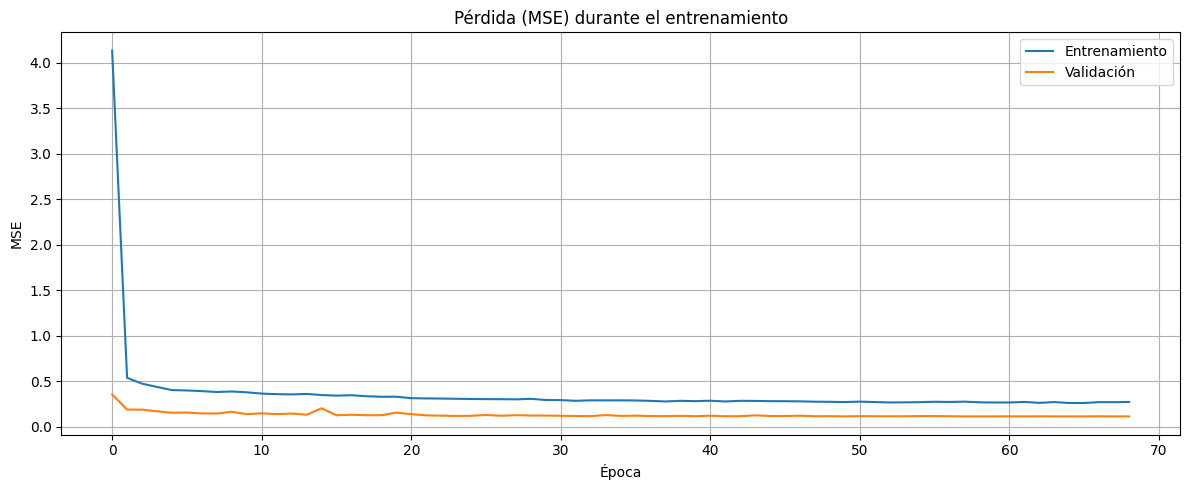

Train loss (MSE): 0.104654, MAE: 0.147252
Val loss (MSE): 0.114396, MAE: 0.152762
Mejor val_loss: 0.114396

Modelo guardado. Listo para la etapa de detección de anomalías.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import time
import pickle

print("ENTRENAMIENTO LSTM CON CARACTERÍSTICAS (CENTROIDES)")
print("=" * 60)

# Cargar centroides (de la etapa 3)
centroids_scaled = np.load('centroids_scaled.npy')  # shape (4, n_tiempo)
n_centroids = centroids_scaled.shape[0]

# Parámetros del artículo
LOOK_BACK = 96
STEP = 4
N_NEURONAS = 80
EPOCHS = 90
BATCH_SIZE = 64
DROPOUT = 0.2
LEARNING_RATE = 0.001

print(f"Configuración: LOOK_BACK={LOOK_BACK}, STEP={STEP}, neuronas={N_NEURONAS}, épocas={EPOCHS}")

# ------------------------------------------------------------
# Preparación de características temporales y medias móviles
# ------------------------------------------------------------
# Necesitamos para cada centroide un DataFrame con las mismas marcas de tiempo que los datos originales (2014)
# Para simplificar, crearemos un índice de tiempo ficticio con frecuencia de 15 min y duración igual al centroide.
# Pero como los centroides son promedios de todos los usuarios, no tienen un índice real asociado.
# Alternativa: calcular las características directamente sobre la serie del centroide, asumiendo que el tiempo es continuo.
# Usaremos funciones auxiliares para calcular medias móviles sobre el array.

def compute_features_from_series(series, freq_min=15):
    """
    series: numpy array 1D de consumo.
    Retorna: DataFrame con columnas: day_of_week, day_of_month, month, hour, minute, timeslice,
             avg_prev_hour, avg_prev_2hour.
    Necesitamos una línea de tiempo ficticia para poder derivar día de semana, etc.
    Asumimos que la serie comienza en el primer día de un mes (por simplicidad).
    Para no complicar, generamos un índice datetime que empiece en 2014-01-01 00:00:00 con frecuencia 15 min.
    """
    n = len(series)
    idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
    df_temp = pd.DataFrame({'consumo': series}, index=idx)

    # Características temporales
    df_temp['day_of_week'] = df_temp.index.dayofweek
    df_temp['day_of_month'] = df_temp.index.day
    df_temp['month'] = df_temp.index.month
    df_temp['hour'] = df_temp.index.hour
    df_temp['minute'] = df_temp.index.minute
    df_temp['timeslice'] = df_temp.index.hour // 4

    # Medias móviles (ventana 4 = 1 hora)
    df_temp['avg_prev_hour'] = df_temp['consumo'].rolling(4, min_periods=1).mean().shift(1)
    df_temp['avg_prev_2hour'] = df_temp['consumo'].rolling(4, min_periods=1).mean().shift(2)

    # Rellenar primeros valores con la media global o con 0 (el artículo no especifica)
    df_temp.fillna(0, inplace=True)

    return df_temp

# ------------------------------------------------------------------
# Crear secuencias para cada centroide con todas las características
# ------------------------------------------------------------------
def create_sequences_with_features(df, look_back, step=1):
    """
    df: DataFrame con columnas 'consumo' y todas las características.
    Retorna X (n_samples, look_back, n_features) e y (n_samples,).
    """
    features_cols = ['consumo', 'day_of_week', 'day_of_month', 'month', 'timeslice',
                     'avg_prev_hour', 'avg_prev_2hour']
    data = df[features_cols].values  # shape (n, n_feat)

    X, y = [], []
    n = len(data)
    for i in range(look_back, n, step):
        X.append(data[i-look_back:i, :])   # ventana de todas las características
        y.append(data[i, 0])                # el consumo real en el siguiente paso
    return np.array(X), np.array(y)

# Acumular todas las secuencias de los 4 centroides
X_list, y_list = [], []
for i in range(n_centroids):
    print(f"Procesando centroide {i+1}/{n_centroids}...")
    df_cent = compute_features_from_series(centroids_scaled[i])
    Xc, yc = create_sequences_with_features(df_cent, LOOK_BACK, step=STEP)
    X_list.append(Xc)
    y_list.append(yc)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
print(f"Total secuencias generadas: {X.shape[0]}, features por paso: {X.shape[2]}")

# Dividir en entrenamiento y validación (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}")

# ------------------------------------------------------------------
# Construcción del modelo LSTM
# ------------------------------------------------------------------
model = Sequential()
model.add(LSTM(N_NEURONAS, input_shape=(LOOK_BACK, X.shape[2]), activation='tanh', recurrent_activation='sigmoid', return_sequences=False))
model.add(Dropout(DROPOUT))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mse', metrics=['mae'])
model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Entrenamiento
start_time = time.time()
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)
elapsed = time.time() - start_time
print(f"Tiempo entrenamiento: {elapsed/60:.2f} minutos")

# ------------------------------------------------------------------
# Resultados y gráficas de pérdida
# ------------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (MSE) durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluación final
train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
print(f"Train loss (MSE): {train_loss:.6f}, MAE: {train_mae:.6f}")
print(f"Val loss (MSE): {val_loss:.6f}, MAE: {val_mae:.6f}")
print(f"Mejor val_loss: {min(history.history['val_loss']):.6f}")

# Guardar modelo y datos
model.save('lstm_model_features.h5')
with open('lstm_training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("\nModelo guardado. Listo para la etapa de detección de anomalías.")

# Etapa 5: Detección de anomalías, inyección de anomalías y concept drift, y cálculo de precisión/recall

Siguiendo el artículo (secciones III‑D y IV):

El algoritmo de detección de anomalías se basa en el error de predicción de la LSTM. Para cada instante t:

Se predice el consumo CP_{t+1}.

Se calcula el error cuadrático δ_{t+1} = (CR_{t+1} - CP_{t+1})².

Se calcula la desviación estándar σ(Δ_k) de los errores de los últimos 7 días (es decir, de las últimas 7×96 = 672 observaciones, aunque el artículo dice "week precedes the actual instant").

Si la desviación estándar de las últimas 24 horas supera 2σ(Δ_k) o es inferior a -2σ(Δ_k), se señala una anomalía. El artículo usa el umbral empírico de 2σ.Pasos a seguir en esta etapa:

Cargar el modelo LSTM entrenado (con los centroides).

Seleccionar un conjunto de consumidores reales de diciembre 2014 para evaluar (por ejemplo, los mismos 300 que usan los autores, aunque no tenemos la lista exacta; usaremos los primeros 300 consumidores del dataset).

Para cada consumidor:

Obtener su serie de consumo de diciembre 2014.

Normalizar con el escalador ajustado con los centroides (o con el escalador del clustering). El artículo no especifica cómo normalizan los datos de test. Asumiremos que usan el escalador entrenado con los centroides (o con los datos de entrenamiento). Punto a consultar.

Inyectar anomalías en el 14% de los puntos (aleatorios) y drifts en el 13% de los puntos (en bloques).

Generar predicciones paso a paso con la LSTM (usando ventana deslizante de 96 pasos, con las mismas características temporales y medias móviles calculadas sobre la marcha).

Calcular errores cuadráticos y aplicar el detector de anomalías.

Comparar las detecciones con las etiquetas reales (anomalías inyectadas, ignorando los drifts) para calcular TP, FP, FN.

In [11]:
# -*- coding: utf-8 -*-
"""
Etapa 5: Detección de anomalías y evaluación (versión final optimizada)
- Paso de predicción: 1 hora (step=4)
- Procesamiento por lotes
- Ajustes de ventanas: 24h = 24 puntos, 7d = 168 puntos
"""

import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import pickle
from tqdm import tqdm
import random

np.random.seed(42)
random.seed(42)

print("DETECCIÓN DE ANOMALÍAS (ETAPA 5 - STEP=4, BATCH)")
print("=" * 60)

# ------------------------------------------------------------
# Parámetros
# ------------------------------------------------------------
LOOK_BACK = 96          # 24 horas (96 puntos de 15 min)
STEP = 4                # muestreo: 1 cada 4 (cada hora)
OBS_PER_DAY = 96
WINDOW_24H = 24         # 24 puntos de error (1 por hora)
WINDOW_7D = 7 * 24      # 168 puntos
SIGMA_THRESHOLD = 2.0
PCT_ANOMALIES = 0.14
PCT_DRIFT = 0.13
N_CONSUMERS = 300

# ------------------------------------------------------------
# Funciones auxiliares (sin cambios)
# ------------------------------------------------------------
def compute_features_from_series(series, freq_min=15):
    n = len(series)
    idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
    df_temp = pd.DataFrame({'consumo': series}, index=idx)
    df_temp['day_of_week'] = df_temp.index.dayofweek
    df_temp['day_of_month'] = df_temp.index.day
    df_temp['month'] = df_temp.index.month
    df_temp['hour'] = df_temp.index.hour
    df_temp['minute'] = df_temp.index.minute
    df_temp['timeslice'] = df_temp.index.hour // 4
    df_temp['avg_prev_hour'] = df_temp['consumo'].rolling(4, min_periods=1).mean().shift(1)
    df_temp['avg_prev_2hour'] = df_temp['consumo'].rolling(4, min_periods=1).mean().shift(2)
    df_temp.fillna(0, inplace=True)
    return df_temp

def inject_anomalies(series, pct, intensity=(2,5)):
    n = len(series)
    num_anom = int(n * pct)
    indices = np.random.choice(n, size=num_anom, replace=False)
    series_mod = series.copy()
    for idx in indices:
        factor = np.random.uniform(*intensity)
        series_mod[idx] *= factor
    return series_mod, indices

def inject_drift(series, pct, centroids_scaled):
    n = len(series)
    duration = max(int(n * pct), OBS_PER_DAY)
    start = np.random.randint(0, n - duration)
    centroide = centroids_scaled[np.random.randint(0, centroids_scaled.shape[0])]
    centroide_scaled = (centroide - np.mean(centroide)) / (np.std(centroide) + 1e-8)
    centroide_adj = centroide_scaled * np.std(series) + np.mean(series)
    seg = centroide_adj[:duration]
    series_mod = series.copy()
    series_mod[start:start+duration] = seg
    mask = np.zeros(n, dtype=bool)
    mask[start:start+duration] = True
    return series_mod, mask

# ------------------------------------------------------------
# Función de predicción por lotes con step=4
# ------------------------------------------------------------
def predict_consumption_batch(series, features_df, look_back, step, model, batch_size=256):
    """
    series: array (n,) de consumo (cada 15 min)
    features_df: DataFrame con características alineadas con series
    look_back: ventana en pasos originales (96 = 24h)
    step: desplazamiento entre predicciones (4 = 1h)
    """
    n = len(series)
    # Índices de inicio de cada ventana (0, step, 2*step, ...)
    start_indices = list(range(0, n - look_back, step))
    n_pred = len(start_indices)

    # 1. Construir ventanas de consumo
    X_windows = np.array([series[i:i+look_back] for i in start_indices], dtype=np.float32)

    # 2. Normalización local
    means = X_windows.mean(axis=1, keepdims=True)
    stds = X_windows.std(axis=1, keepdims=True)
    stds[stds == 0] = 1.0
    X_norm = (X_windows - means) / stds

    # 3. Ventanas de características (mismas posiciones)
    feat_cols = ['day_of_week','day_of_month','month','timeslice','avg_prev_hour','avg_prev_2hour']
    feat_all = features_df[feat_cols].values.astype(np.float32)
    feat_windows = np.zeros((n_pred, look_back, 6), dtype=np.float32)
    for idx, i in enumerate(start_indices):
        feat_windows[idx] = feat_all[i:i+look_back]

    # 4. Concatenar
    combined = np.concatenate([X_norm[..., np.newaxis], feat_windows], axis=-1)

    # 5. Predicción por lotes
    preds_norm = model.predict(combined, batch_size=batch_size, verbose=0).flatten()
    preds = preds_norm * stds.flatten() + means.flatten()

    # 6. Valores reales (punto siguiente a cada ventana)
    target_indices = [i + look_back for i in start_indices]
    real = series[target_indices]
    errors = (real - preds) ** 2

    return preds, errors, target_indices

# ------------------------------------------------------------
# Cargar modelo y datos
# ------------------------------------------------------------
model = load_model('lstm_model_features.h5', compile=False)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
centroids = np.load('centroids_scaled.npy')

# Cargar datos de test (diciembre 2014)
# Asegurar que df_2014 existe o cargar desde archivo
df_test = df_2014[df_2014.index.month == 12].copy()
consumers = df_test.columns[:N_CONSUMERS]

# ------------------------------------------------------------
# Bucle principal
# ------------------------------------------------------------
total_tp = total_fp = total_fn = total_anom = 0

for consumer in tqdm(consumers, desc="Evaluando"):
    serie = df_test[consumer].values.astype(np.float32)
    if len(serie) < LOOK_BACK + WINDOW_7D * STEP:
        continue

    # Inyección
    serie_anom, idx_anom = inject_anomalies(serie, PCT_ANOMALIES)
    serie_final, mask_drift = inject_drift(serie_anom, PCT_DRIFT, centroids)
    df_feat = compute_features_from_series(serie_final)

    # Predicción
    _, errors, target_indices = predict_consumption_batch(serie_final, df_feat, LOOK_BACK, STEP, model)
    n_errors = len(errors)

    # Detección de anomalías (ventanas móviles)
    detections = np.zeros(n_errors, dtype=bool)
    for i in range(WINDOW_7D, n_errors):
        std24 = np.std(errors[i-WINDOW_24H:i])
        std7d = np.std(errors[i-WINDOW_7D:i])
        if std7d == 0:
            continue
        if std24 > SIGMA_THRESHOLD * std7d:
            detections[i] = True

    # Etiquetas reales: anomalía si el punto predicho está en idx_anom
    real_anom = np.zeros(n_errors, dtype=bool)
    for i, t_idx in enumerate(target_indices):
        if t_idx in idx_anom and not mask_drift[t_idx]:
            real_anom[i] = True

    # Máscara de drift: excluir si el punto predicho está en zona de drift
    relevant = np.array([not mask_drift[t] for t in target_indices])

    tp = np.sum(detections & real_anom & relevant)
    fp = np.sum(detections & ~real_anom & relevant)
    fn = np.sum(~detections & real_anom & relevant)

    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_anom += np.sum(real_anom & relevant)

# ------------------------------------------------------------
# Resultados finales
# ------------------------------------------------------------
precision = total_tp / (total_tp + total_fp) if (total_tp+total_fp) else 0.0
recall = total_tp / (total_tp + total_fn) if (total_tp+total_fn) else 0.0

print("\n" + "=" * 60)
print("RESULTADOS DE DETECCIÓN DE ANOMALÍAS")
print("=" * 60)
print(f"Total anomalías relevantes evaluadas: {total_anom}")
print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"Referencia artículo: Precision=78%, Recall=88%")

DETECCIÓN DE ANOMALÍAS (ETAPA 5 - STEP=4, BATCH)


Evaluando:   0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_4747/612619967.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
Evaluando:   0%|          | 1/300 [00:01<08:59,  1.80s/it]/tmp/ipykernel_4747/612619967.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
Evaluando:   1%|          | 2/300 [00:03<08:28,  1.71s/it]/tmp/ipykernel_4747/612619967.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
Evaluando:   1%|          | 3/300 [00:04<07:25,  1.50s/it]/tmp/ipykernel_4747/612619967.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx 


RESULTADOS DE DETECCIÓN DE ANOMALÍAS
Total anomalías relevantes evaluadas: 26206
Precision: 0.1786 (17.9%)
Recall:    0.0006 (0.1%)
Referencia artículo: Precision=78%, Recall=88%


# Opción 1: Predicción cada 15 min (step=1) con procesamiento por lotes
A continuación, el código adaptado para predecir cada 15 minutos (resolución completa), manteniendo el procesamiento por lotes para que sea computacionalmente viable. Las ventanas de desviación estándar se ajustan a la resolución original:

24 horas → WINDOW_24H = 96 puntos

7 días → WINDOW_7D = 672 puntos

Importante: El modelo fue entrenado con un muestreo de 1 cada 4 (cada hora), por lo que predecir cada 15 min puede no mejorar los resultados (el modelo no fue entrenado para esa resolución). Sin embargo, es un experimento válido para evaluar si el detector se beneficia de una mayor densidad de errores.

In [12]:
# -*- coding: utf-8 -*-
"""
Etapa 5 (Opción 1): Predicción cada 15 min (step=1)
- Procesamiento por lotes
- Ventanas: 24h = 96 puntos, 7d = 672 puntos
"""

import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import pickle
from tqdm import tqdm
import random

np.random.seed(42)
random.seed(42)

print("DETECCIÓN DE ANOMALÍAS (OPCIÓN 1 - STEP=1, BATCH)")
print("=" * 60)

# ------------------------------------------------------------
# Parámetros (resolución original)
# ------------------------------------------------------------
LOOK_BACK = 96          # 24 horas en puntos de 15 min
STEP = 1                # predecir cada punto (cada 15 min)
OBS_PER_DAY = 96
WINDOW_24H = 96         # 24h en puntos de error
WINDOW_7D = 7 * 96      # 672 puntos
SIGMA_THRESHOLD = 2.0
PCT_ANOMALIES = 0.14
PCT_DRIFT = 0.13
N_CONSUMERS = 300

# ------------------------------------------------------------
# Funciones auxiliares (sin cambios)
# ------------------------------------------------------------
def compute_features_from_series(series, freq_min=15):
    n = len(series)
    idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
    df_temp = pd.DataFrame({'consumo': series}, index=idx)
    df_temp['day_of_week'] = df_temp.index.dayofweek
    df_temp['day_of_month'] = df_temp.index.day
    df_temp['month'] = df_temp.index.month
    df_temp['hour'] = df_temp.index.hour
    df_temp['minute'] = df_temp.index.minute
    df_temp['timeslice'] = df_temp.index.hour // 4
    df_temp['avg_prev_hour'] = df_temp['consumo'].rolling(4, min_periods=1).mean().shift(1)
    df_temp['avg_prev_2hour'] = df_temp['consumo'].rolling(4, min_periods=1).mean().shift(2)
    df_temp.fillna(0, inplace=True)
    return df_temp

def inject_anomalies(series, pct, intensity=(2,5)):
    n = len(series)
    num_anom = int(n * pct)
    indices = np.random.choice(n, size=num_anom, replace=False)
    series_mod = series.copy()
    for idx in indices:
        factor = np.random.uniform(*intensity)
        series_mod[idx] *= factor
    return series_mod, indices

def inject_drift(series, pct, centroids_scaled):
    n = len(series)
    duration = max(int(n * pct), OBS_PER_DAY)
    start = np.random.randint(0, n - duration)
    centroide = centroids_scaled[np.random.randint(0, centroids_scaled.shape[0])]
    centroide_scaled = (centroide - np.mean(centroide)) / (np.std(centroide) + 1e-8)
    centroide_adj = centroide_scaled * np.std(series) + np.mean(series)
    seg = centroide_adj[:duration]
    series_mod = series.copy()
    series_mod[start:start+duration] = seg
    mask = np.zeros(n, dtype=bool)
    mask[start:start+duration] = True
    return series_mod, mask

# ------------------------------------------------------------
# Función de predicción por lotes con step=1
# ------------------------------------------------------------
def predict_consumption_batch(series, features_df, look_back, model, batch_size=256):
    n = len(series)
    n_pred = n - look_back
    # Índices de inicio de cada ventana (0,1,2,...)
    start_indices = list(range(n_pred))

    # 1. Construir ventanas de consumo
    X_windows = np.array([series[i:i+look_back] for i in start_indices], dtype=np.float32)

    # 2. Normalización local
    means = X_windows.mean(axis=1, keepdims=True)
    stds = X_windows.std(axis=1, keepdims=True)
    stds[stds == 0] = 1.0
    X_norm = (X_windows - means) / stds

    # 3. Ventanas de características
    feat_cols = ['day_of_week','day_of_month','month','timeslice','avg_prev_hour','avg_prev_2hour']
    feat_all = features_df[feat_cols].values.astype(np.float32)
    feat_windows = np.zeros((n_pred, look_back, 6), dtype=np.float32)
    for idx, i in enumerate(start_indices):
        feat_windows[idx] = feat_all[i:i+look_back]

    # 4. Concatenar
    combined = np.concatenate([X_norm[..., np.newaxis], feat_windows], axis=-1)

    # 5. Predicción por lotes
    preds_norm = model.predict(combined, batch_size=batch_size, verbose=0).flatten()
    preds = preds_norm * stds.flatten() + means.flatten()

    # 6. Valores reales (punto siguiente a cada ventana)
    target_indices = [i + look_back for i in start_indices]
    real = series[target_indices]
    errors = (real - preds) ** 2

    return preds, errors, target_indices

# ------------------------------------------------------------
# Cargar modelo y datos
# ------------------------------------------------------------
model = load_model('lstm_model_features.h5', compile=False)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
centroids = np.load('centroids_scaled.npy')

# Asegurar que df_2014 esté disponible
df_test = df_2014[df_2014.index.month == 12].copy()
consumers = df_test.columns[:N_CONSUMERS]

# ------------------------------------------------------------
# Bucle principal
# ------------------------------------------------------------
total_tp = total_fp = total_fn = total_anom = 0

for consumer in tqdm(consumers, desc="Evaluando"):
    serie = df_test[consumer].values.astype(np.float32)
    if len(serie) < LOOK_BACK + WINDOW_7D:
        continue

    serie_anom, idx_anom = inject_anomalies(serie, PCT_ANOMALIES)
    serie_final, mask_drift = inject_drift(serie_anom, PCT_DRIFT, centroids)
    df_feat = compute_features_from_series(serie_final)

    _, errors, target_indices = predict_consumption_batch(serie_final, df_feat, LOOK_BACK, model)
    n_errors = len(errors)

    # Detección con ventanas móviles (resolución completa)
    detections = np.zeros(n_errors, dtype=bool)
    for i in range(WINDOW_7D, n_errors):
        std24 = np.std(errors[i-WINDOW_24H:i])
        std7d = np.std(errors[i-WINDOW_7D:i])
        if std7d == 0:
            continue
        if std24 > SIGMA_THRESHOLD * std7d:
            detections[i] = True

    # Etiquetas reales
    real_anom = np.zeros(n_errors, dtype=bool)
    for i, t_idx in enumerate(target_indices):
        if t_idx in idx_anom and not mask_drift[t_idx]:
            real_anom[i] = True

    relevant = np.array([not mask_drift[t] for t in target_indices])

    tp = np.sum(detections & real_anom & relevant)
    fp = np.sum(detections & ~real_anom & relevant)
    fn = np.sum(~detections & real_anom & relevant)

    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_anom += np.sum(real_anom & relevant)

precision = total_tp / (total_tp + total_fp) if (total_tp+total_fp) else 0.0
recall = total_tp / (total_tp + total_fn) if (total_tp+total_fn) else 0.0

print("\n" + "=" * 60)
print("RESULTADOS (OPCIÓN 1 - STEP=1)")
print("=" * 60)
print(f"Total anomalías relevantes evaluadas: {total_anom}")
print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"Referencia artículo: Precision=78%, Recall=88%")

DETECCIÓN DE ANOMALÍAS (OPCIÓN 1 - STEP=1, BATCH)


Evaluando:   0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_4747/2670772167.py:39: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
Evaluando:   0%|          | 1/300 [00:07<34:55,  7.01s/it]/tmp/ipykernel_4747/2670772167.py:39: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
Evaluando:   1%|          | 2/300 [00:10<25:45,  5.19s/it]/tmp/ipykernel_4747/2670772167.py:39: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  idx = pd.date_range(start='2014-01-01', periods=n, freq=f'{freq_min}T')
Evaluando:   1%|          | 3/300 [00:14<22:41,  4.58s/it]/tmp/ipykernel_4747/2670772167.py:39: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  


RESULTADOS (OPCIÓN 1 - STEP=1)
Total anomalías relevantes evaluadas: 104554
Precision: 0.1217 (12.2%)
Recall:    0.0007 (0.1%)
Referencia artículo: Precision=78%, Recall=88%
